In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm

In [2]:
import os, glob, random
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, skew, kurtosis

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

from google.colab import drive

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATASET_PATH = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")

all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(DATASET_PATH, "**", ext), recursive=True)

print("Total images found:", len(all_imgs))
print("Sample paths:", all_imgs[:5])

Total images found: 760
Sample paths: ['/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1024).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (566).jpg']


Labeling

In [6]:
def infer_label_from_path(p):
    lp = p.lower()

    pos_keys = ["jaundice", "icteric", "positive", "pos", "case", "patient", "affected", "yellow"]
    neg_keys = ["normal", "control", "negative", "neg", "healthy", "non"]

    if any(k in lp for k in pos_keys):
        return 1
    if any(k in lp for k in neg_keys):
        return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p, l) for p, l in pairs if l is not None]

imgs = [p for p, l in pairs]
y_all = np.array([l for p, l in pairs])

print("Total labeled:", len(pairs))
print("Class counts (0=Normal, 1=Jaundice):", np.bincount(y_all))

Total labeled: 760
Class counts (0=Normal, 1=Jaundice): [560 200]


ROI Functions

In [7]:
# ----------------------------
# Forehead ROI (improved)
# ----------------------------
def get_forehead_box(img_bgr):
    h, w = img_bgr.shape[:2]

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    candidates = []
    min_area = max(300, int(0.002 * h * w))
    for i in range(1, num_labels):
        x, y, bw, bh, area = stats[i]
        if area >= min_area:
            candidates.append((i, x, y, bw, bh, area))

    if candidates:
        candidates = sorted(candidates, key=lambda t: (t[2], -t[5]))
        _, x, y, bw, bh, area = candidates[0]

        pad_x = int(0.05 * bw)
        pad_y = int(0.05 * bh)
        x = max(0, x - pad_x)
        y = max(0, y - pad_y)
        bw = min(w - x, bw + 2 * pad_x)
        bh = min(h - y, bh + 2 * pad_y)

        x1 = max(0, x + int(0.18 * bw))
        x2 = min(w, x + int(0.68 * bw))
        y1 = max(0, y + int(0.08 * bh))
        y2 = min(h, y + int(0.22 * bh))
    else:
        x1 = int(0.28 * w)
        x2 = int(0.58 * w)
        y1 = int(0.10 * h)
        y2 = int(0.22 * h)

    if (x2 - x1) < 12 or (y2 - y1) < 12:
        x1 = int(0.28 * w)
        x2 = int(0.58 * w)
        y1 = int(0.10 * h)
        y2 = int(0.22 * h)

    return x1, y1, x2, y2, mask


def extract_forehead_roi(img_bgr):
    x1, y1, x2, y2, _ = get_forehead_box(img_bgr)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


# ----------------------------
# Chest ROI
# ----------------------------
def extract_chest_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)
    y1 = int(0.40 * h)
    y2 = int(0.80 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


# ----------------------------
# Abdomen ROI
# ----------------------------
def extract_abdomen_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)
    y1 = int(0.60 * h)
    y2 = int(0.92 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

ROI Preview

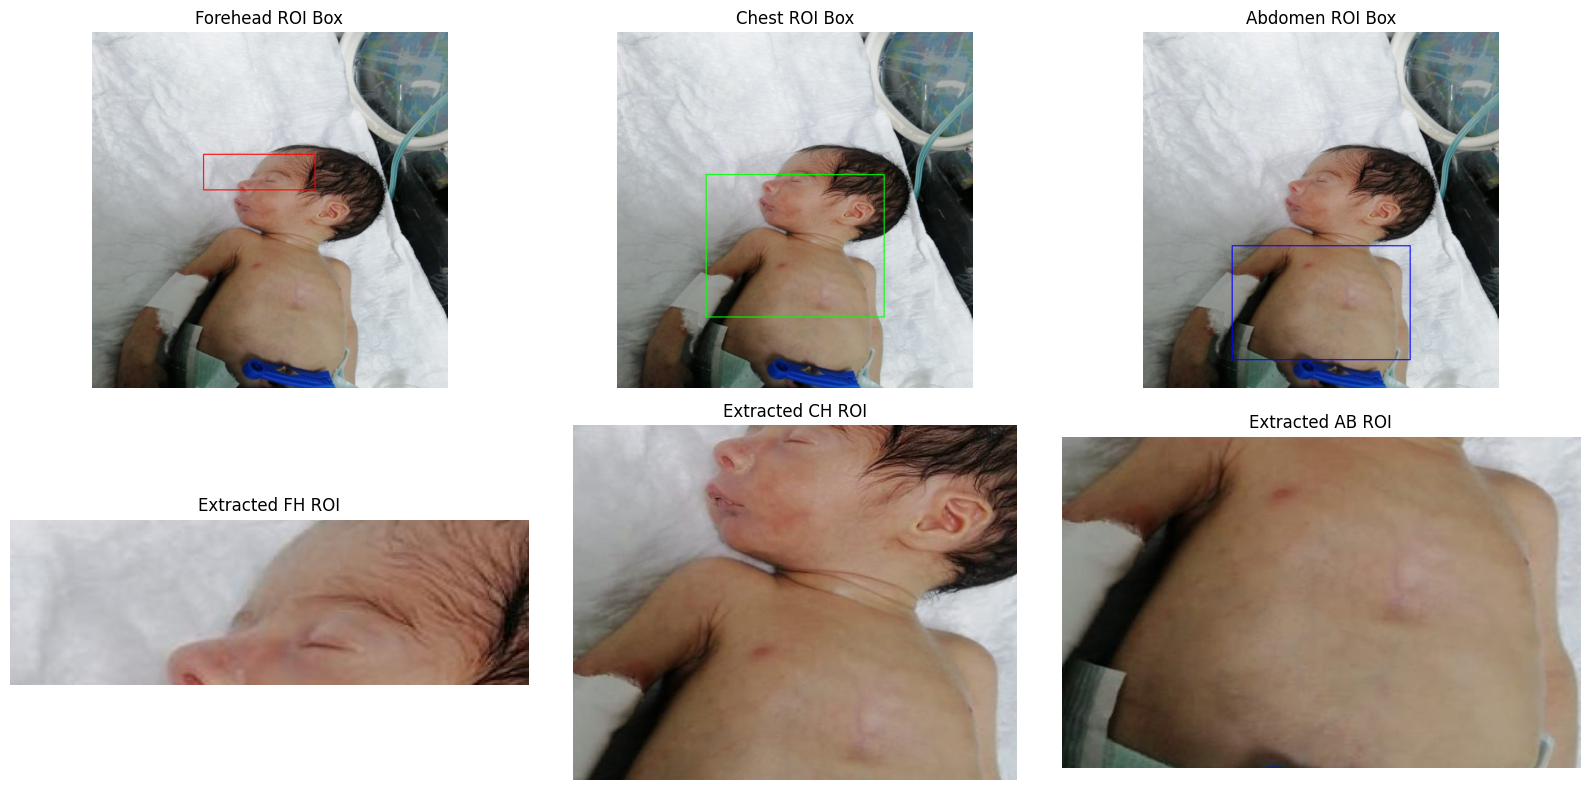

In [8]:
sample_path = imgs[0]
sample_img = cv2.imread(sample_path)
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# Forehead
x1, y1, x2, y2, _ = get_forehead_box(sample_img)
vis_fh = sample_rgb.copy()
cv2.rectangle(vis_fh, (x1, y1), (x2, y2), (255, 0, 0), 2)
fh_roi_rgb = cv2.cvtColor(extract_forehead_roi(sample_img), cv2.COLOR_BGR2RGB)

# Chest
h, w = sample_img.shape[:2]
vis_ch = sample_rgb.copy()
cv2.rectangle(vis_ch, (int(0.25*w), int(0.40*h)), (int(0.75*w), int(0.80*h)), (0, 255, 0), 2)
ch_roi_rgb = cv2.cvtColor(extract_chest_roi(sample_img), cv2.COLOR_BGR2RGB)

# Abdomen
vis_ab = sample_rgb.copy()
cv2.rectangle(vis_ab, (int(0.25*w), int(0.60*h)), (int(0.75*w), int(0.92*h)), (0, 0, 255), 2)
ab_roi_rgb = cv2.cvtColor(extract_abdomen_roi(sample_img), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(vis_fh)
plt.title("Forehead ROI Box")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(vis_ch)
plt.title("Chest ROI Box")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(vis_ab)
plt.title("Abdomen ROI Box")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(fh_roi_rgb)
plt.title("Extracted FH ROI")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(ch_roi_rgb)
plt.title("Extracted CH ROI")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(ab_roi_rgb)
plt.title("Extracted AB ROI")
plt.axis("off")

plt.tight_layout()
plt.show()

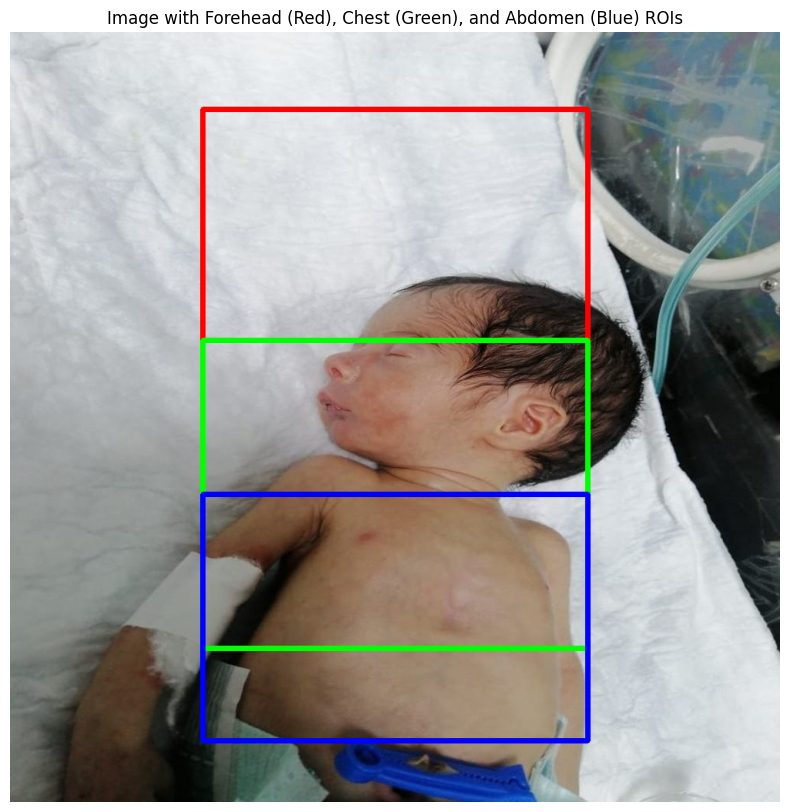

In [9]:
sample_img_path = pairs[0][0]
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Create a copy to draw ROIs on
img_with_rois = img_rgb.copy()
h, w = img_with_rois.shape[:2]

# Define colors for each ROI
forehead_color = (255, 0, 0)  # Red
chest_color = (0, 255, 0)     # Green
abdomen_color = (0, 0, 255)   # Blue
thickness = 5

# Forehead ROI coordinates
x1_f, x2_f = int(0.25*w), int(0.75*w)
y1_f, y2_f = int(0.10*h), int(0.40*h)
cv2.rectangle(img_with_rois, (x1_f, y1_f), (x2_f, y2_f), forehead_color, thickness)

# Chest ROI coordinates
x1_c, x2_c = int(0.25*w), int(0.75*w)
y1_c, y2_c = int(0.40*h), int(0.80*h)
cv2.rectangle(img_with_rois, (x1_c, y1_c), (x2_c, y2_c), chest_color, thickness)

# Abdomen ROI coordinates
x1_a, x2_a = int(0.25*w), int(0.75*w)
y1_a, y2_a = int(0.60*h), int(0.92*h)
cv2.rectangle(img_with_rois, (x1_a, y1_a), (x2_a, y2_a), abdomen_color, thickness)

plt.figure(figsize=(10, 10))
plt.imshow(img_with_rois)
plt.title('Image with Forehead (Red), Chest (Green), and Abdomen (Blue) ROIs')
plt.axis('off')
plt.show()

Preprocess + Skin Mask + Feature Extraction

In [10]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)

    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0

    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))

    out = cv2.merge([b, g, r])
    return np.clip(out, 0, 255).astype(np.uint8)


def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    L2 = clahe.apply(L)

    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)


def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr


def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)

    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)

    return mask


def masked_stats(channel, mask):
    vals = channel[mask == 255].astype(np.float32)

    if vals.size < 30:
        return (np.nan,) * 6

    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )


def extract_features_from_roi(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)

    if np.sum(mask == 255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8) * 255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:, :, 0]
    G = roi_rgb[:, :, 1]
    B = roi_rgb[:, :, 2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))
    rg_balance = float((Rm - Gm) / (Rm + Gm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom)
    g_ch = float(Gm / denom)
    b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask == 255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0, 180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:, :, 0]
    a = lab[:, :, 1]
    b = lab[:, :, 2]

    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask == 255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,
        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "RG_balance": rg_balance,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,
        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,
        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop,
    }

    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

Preprocess Preview

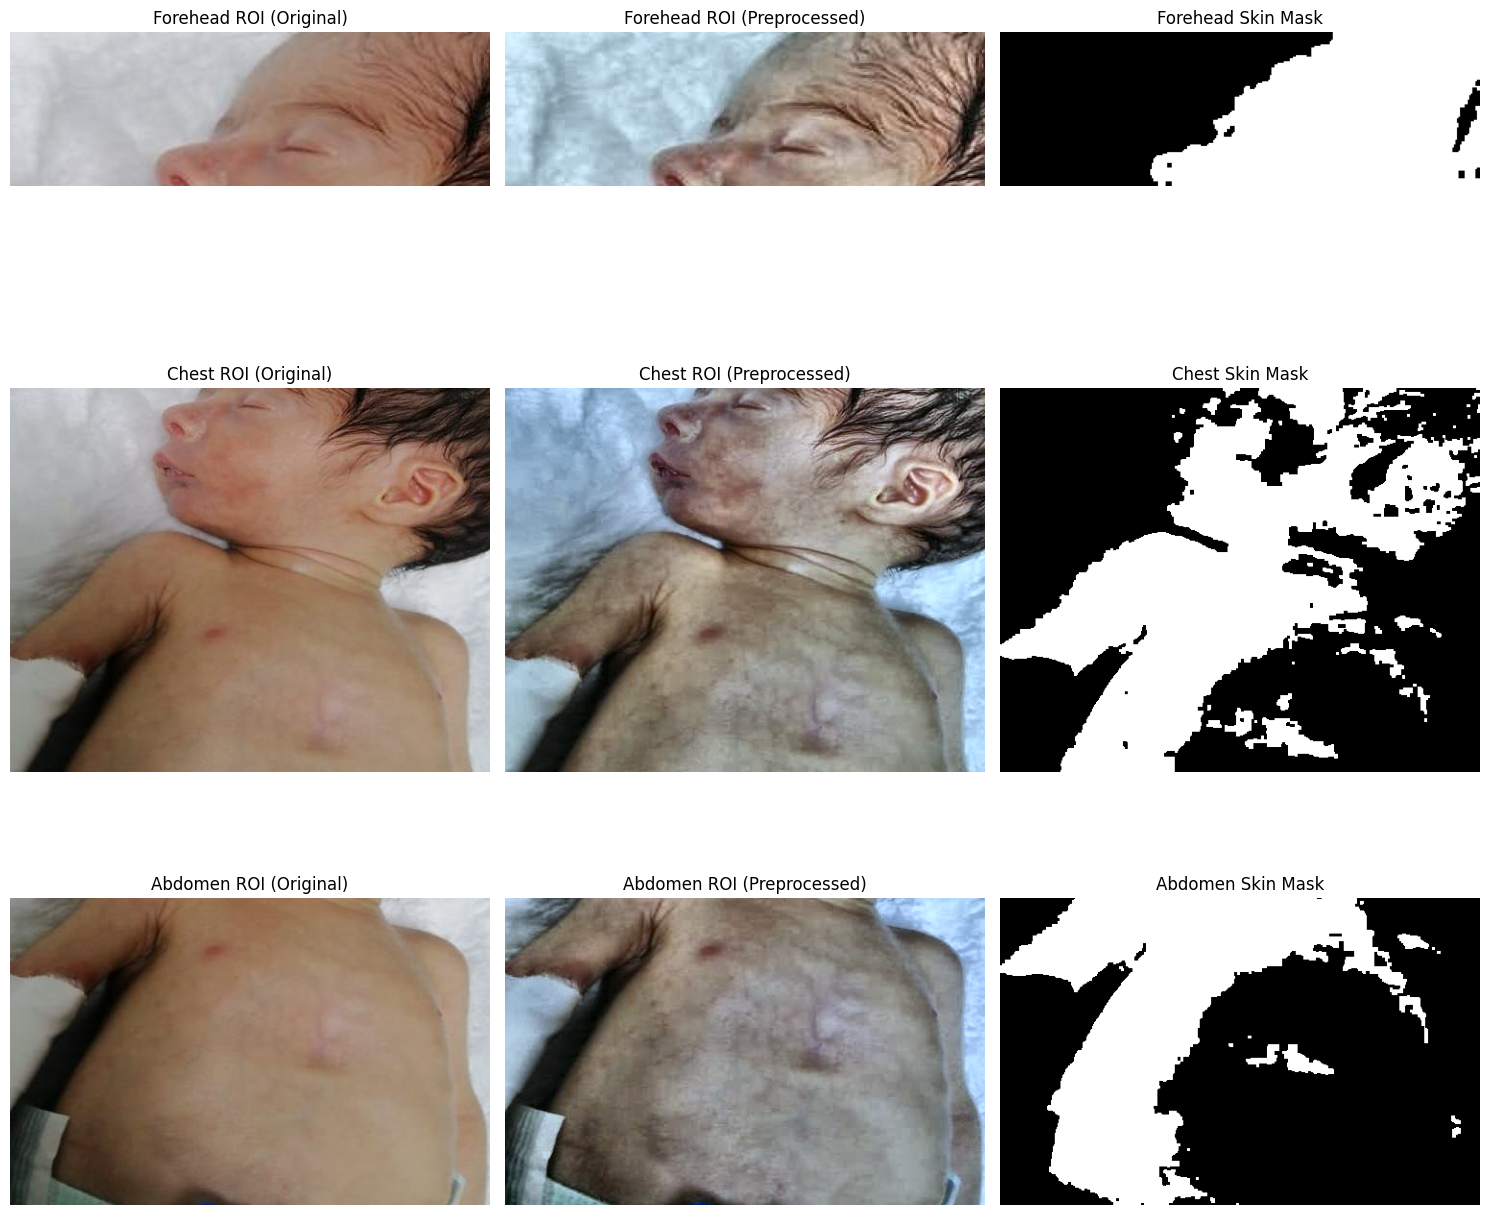

In [11]:
img = cv2.imread(imgs[0])

forehead_roi_original = extract_forehead_roi(img)
chest_roi_original = extract_chest_roi(img)
abdomen_roi_original = extract_abdomen_roi(img)

forehead_roi_preprocessed = preprocess_roi(forehead_roi_original)
chest_roi_preprocessed = preprocess_roi(chest_roi_original)
abdomen_roi_preprocessed = preprocess_roi(abdomen_roi_original)

forehead_mask = skin_mask_hsv(forehead_roi_preprocessed)
chest_mask = skin_mask_hsv(chest_roi_preprocessed)
abdomen_mask = skin_mask_hsv(abdomen_roi_preprocessed)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Forehead
axes[0, 0].imshow(cv2.cvtColor(forehead_roi_original, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Forehead ROI (Original)")
axes[0, 0].axis("off")

axes[0, 1].imshow(cv2.cvtColor(forehead_roi_preprocessed, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("Forehead ROI (Preprocessed)")
axes[0, 1].axis("off")

axes[0, 2].imshow(forehead_mask, cmap="gray")
axes[0, 2].set_title("Forehead Skin Mask")
axes[0, 2].axis("off")

# Chest
axes[1, 0].imshow(cv2.cvtColor(chest_roi_original, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Chest ROI (Original)")
axes[1, 0].axis("off")

axes[1, 1].imshow(cv2.cvtColor(chest_roi_preprocessed, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Chest ROI (Preprocessed)")
axes[1, 1].axis("off")

axes[1, 2].imshow(chest_mask, cmap="gray")
axes[1, 2].set_title("Chest Skin Mask")
axes[1, 2].axis("off")

# Abdomen
axes[2, 0].imshow(cv2.cvtColor(abdomen_roi_original, cv2.COLOR_BGR2RGB))
axes[2, 0].set_title("Abdomen ROI (Original)")
axes[2, 0].axis("off")

axes[2, 1].imshow(cv2.cvtColor(abdomen_roi_preprocessed, cv2.COLOR_BGR2RGB))
axes[2, 1].set_title("Abdomen ROI (Preprocessed)")
axes[2, 1].axis("off")

axes[2, 2].imshow(abdomen_mask, cmap="gray")
axes[2, 2].set_title("Abdomen Skin Mask")
axes[2, 2].axis("off")

plt.tight_layout()
plt.show()

Build Combined Feature DataFrame

In [12]:
rows = []
failed = 0

for p, label in tqdm(pairs, desc="Extracting FH/CH/AB features"):
    img = cv2.imread(p)

    if img is None:
        failed += 1
        continue

    fh = extract_forehead_roi(img)
    ch = extract_chest_roi(img)
    ab = extract_abdomen_roi(img)

    if fh is None or ch is None or ab is None:
        failed += 1
        continue

    try:
        fh_feat = extract_features_from_roi(fh)
        ch_feat = extract_features_from_roi(ch)
        ab_feat = extract_features_from_roi(ab)
    except:
        failed += 1
        continue

    row = {"path": p, "label": int(label)}
    row.update({f"FH_{k}": v for k, v in fh_feat.items()})
    row.update({f"CH_{k}": v for k, v in ch_feat.items()})
    row.update({f"AB_{k}": v for k, v in ab_feat.items()})

    rows.append(row)

df_all = pd.DataFrame(rows)

print("Combined feature DF:", df_all.shape)
print("Failed:", failed)
print(df_all["label"].value_counts())
df_all.head()

Extracting FH/CH/AB features: 100%|██████████| 760/760 [07:40<00:00,  1.65it/s]

Combined feature DF: (760, 83)
Failed: 0
label
0    560
1    200
Name: count, dtype: int64


,path,label,FH_R_mean,FH_G_mean,FH_B_mean,FH_R_std,FH_G_std,FH_B_std,FH_R_p90,FH_G_p90,...,AB_S_mean,AB_V_mean,AB_V_std,AB_Hue_peak_bin,AB_L_mean,AB_a_mean,AB_Lab_b_mean,AB_Lab_b_p90,AB_yellow_prop,AB_YGI_x_b
0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,153.930222,130.806946,117.704636,32.803490,34.178677,33.234543,191.0,170.0,...,54.757210,117.766083,28.167379,1.0,115.199997,130.831497,136.438614,140.0,0.229696,325.117093
1,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,123.016533,115.415611,89.494461,31.499975,32.291981,30.882174,171.0,164.0,...,96.580063,151.865494,38.708691,1.0,133.264435,138.909378,144.334549,154.0,0.230641,394.999905
2,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,154.651062,122.428192,107.573769,43.065014,43.274124,43.228828,204.0,173.0,...,75.608063,128.315277,45.169415,0.0,113.481529,138.528198,135.857864,140.0,0.212285,329.328092
3,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,154.578079,124.825294,118.616150,57.491440,48.649300,47.339943,226.0,185.0,...,52.880051,177.885681,42.817516,0.0,163.562134,137.114136,135.620560,145.0,0.204689,310.507309
4,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...,0,127.781494,110.722099,105.935638,34.988541,32.297310,32.186501,173.0,152.0,...,40.961773,87.058746,31.533703,2.0,89.306404,128.047729,133.569687,135.0,0.150108,304.651479


Train/Test Split

In [13]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df_all,
    df_all["label"].astype(int).values,
    test_size=0.2,
    random_state=42,
    stratify=df_all["label"].astype(int).values
)

print("Train shape:", X_train_df.shape)
print("Test shape:", X_test_df.shape)
print("Train class counts:\n", X_train_df["label"].value_counts())
print("Test class counts:\n", X_test_df["label"].value_counts())

Train shape: (608, 83)
Test shape: (152, 83)
Train class counts:
 label
0    448
1    160
Name: count, dtype: int64
Test class counts:
 label
0    112
1     40
Name: count, dtype: int64


Train-only Significant Feature Selection

In [14]:
def select_significant_region_features(train_df, prefix, p_thresh=0.05):
    cols = [c for c in train_df.columns if c.startswith(prefix + "_")]
    results = []

    for col in cols:
        c0 = train_df.loc[train_df["label"] == 0, col].dropna()
        c1 = train_df.loc[train_df["label"] == 1, col].dropna()

        if len(c0) < 10 or len(c1) < 10:
            continue

        t_stat, p_val = ttest_ind(c0, c1, equal_var=False)
        results.append({
            "Feature": col,
            "Mean_0": float(np.mean(c0)),
            "Mean_1": float(np.mean(c1)),
            "t_stat": float(t_stat),
            "p_value": float(p_val)
        })

    res_df = pd.DataFrame(results).sort_values("p_value")
    sig_cols = res_df.loc[res_df["p_value"] < p_thresh, "Feature"].tolist()

    if len(sig_cols) == 0:
        sig_cols = cols.copy()

    return res_df, sig_cols


ttest_fh, sig_fh = select_significant_region_features(X_train_df, "FH")
ttest_ch, sig_ch = select_significant_region_features(X_train_df, "CH")
ttest_ab, sig_ab = select_significant_region_features(X_train_df, "AB")

print("FH significant features:", len(sig_fh))
print("CH significant features:", len(sig_ch))
print("AB significant features:", len(sig_ab))

print("\nTop FH features:")
print(ttest_fh.head(10)[["Feature", "p_value"]])

print("\nTop CH features:")
print(ttest_ch.head(10)[["Feature", "p_value"]])

print("\nTop AB features:")
print(ttest_ab.head(10)[["Feature", "p_value"]])

FH significant features: 8
CH significant features: 22
AB significant features: 23

Top FH features:
            Feature   p_value
22        FH_a_mean  0.000868
14          FH_g_ch  0.002384
5          FH_B_std  0.008550
3          FH_R_std  0.016398
12    FH_RG_balance  0.020556
19         FH_V_std  0.027433
4          FH_G_std  0.035687
6          FH_R_p90  0.036544
16        FH_H_mean  0.062557
20  FH_Hue_peak_bin  0.087072

Top CH features:
          Feature       p_value
2       CH_B_mean  1.111699e-18
11    CH_G_over_B  8.367496e-17
15        CH_b_ch  3.404919e-16
24   CH_Lab_b_p90  4.290250e-15
9          CH_YGI  1.349531e-14
26     CH_YGI_x_b  2.090592e-14
17      CH_S_mean  5.597845e-14
23  CH_Lab_b_mean  8.885863e-14
21      CH_L_mean  7.101809e-12
1       CH_G_mean  2.048874e-11

Top AB features:
          Feature       p_value
24   AB_Lab_b_p90  8.003629e-12
2       AB_B_mean  9.934334e-12
15        AB_b_ch  3.591698e-11
17      AB_S_mean  1.267454e-10
11    AB_G_over_B  8.

Build Region Matrices

In [15]:
Xfh_train = X_train_df[sig_fh]
Xch_train = X_train_df[sig_ch]
Xab_train = X_train_df[sig_ab]

Xfh_test = X_test_df[sig_fh]
Xch_test = X_test_df[sig_ch]
Xab_test = X_test_df[sig_ab]

imp_fh = SimpleImputer(strategy="median")
imp_ch = SimpleImputer(strategy="median")
imp_ab = SimpleImputer(strategy="median")

Xfh_train = imp_fh.fit_transform(Xfh_train)
Xch_train = imp_ch.fit_transform(Xch_train)
Xab_train = imp_ab.fit_transform(Xab_train)

Xfh_test = imp_fh.transform(Xfh_test)
Xch_test = imp_ch.transform(Xch_test)
Xab_test = imp_ab.transform(Xab_test)

Train 3 Separate SVM Models

In [16]:
def make_svm():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ])

m_fh = make_svm()
m_ch = make_svm()
m_ab = make_svm()

m_fh.fit(Xfh_train, y_train)
m_ch.fit(Xch_train, y_train)
m_ab.fit(Xab_train, y_train)

prob_fh = m_fh.predict_proba(Xfh_test)[:, 1]
prob_ch = m_ch.predict_proba(Xch_test)[:, 1]
prob_ab = m_ab.predict_proba(Xab_test)[:, 1]

print("AUC FH:", roc_auc_score(y_test, prob_fh))
print("AUC CH:", roc_auc_score(y_test, prob_ch))
print("AUC AB:", roc_auc_score(y_test, prob_ab))

AUC FH: 0.703125
AUC CH: 0.7498883928571429
AUC AB: 0.75625


Late Fusion (Average)

In [17]:
prob_avg = (prob_fh + prob_ch + prob_ab) / 3.0
late_auc = roc_auc_score(y_test, prob_avg)

print("Late Fusion (Average) AUC:", late_auc)

Late Fusion (Average) AUC: 0.7912946428571428


ROC Curve

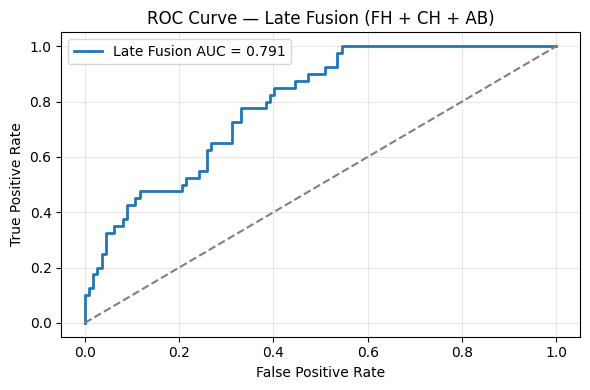

In [19]:
fpr, tpr, thr = roc_curve(y_test, prob_avg)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Late Fusion AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Late Fusion (FH + CH + AB)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Youden Threshold + Report

In [20]:
j = tpr - fpr
best_idx = np.argmax(j)
best_thr = thr[best_idx]

print("Late Fusion AUC:", roc_auc_score(y_test, prob_avg))
print("Best Threshold (Youden J):", best_thr)
print("At Youden point -> FPR:", fpr[best_idx], "TPR(Recall):", tpr[best_idx])

y_pred = (prob_avg >= best_thr).astype(int)

print("\n=== Report @ Youden Threshold (Late Fusion) ===")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Late Fusion AUC: 0.7912946428571428
Best Threshold (Youden J): 0.19581894664968366
At Youden point -> FPR: 0.5446428571428571 TPR(Recall): 1.0

=== Report @ Youden Threshold (Late Fusion) ===
              precision    recall  f1-score   support

           0     1.0000    0.4554    0.6258       112
           1     0.3960    1.0000    0.5674        40

    accuracy                         0.5987       152
   macro avg     0.6980    0.7277    0.5966       152
weighted avg     0.8411    0.5987    0.6104       152

Confusion Matrix:
 [[51 61]
 [ 0 40]]


Confusion Matrix Plot

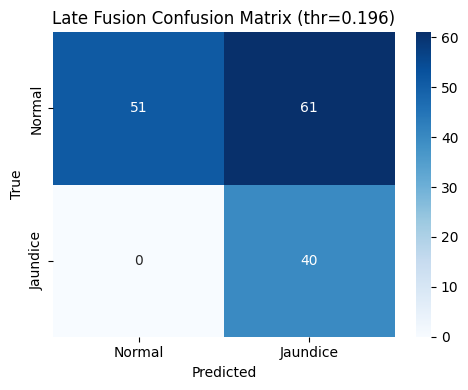

In [21]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Jaundice"],
    yticklabels=["Normal", "Jaundice"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Late Fusion Confusion Matrix (thr={best_thr:.3f})")
plt.tight_layout()
plt.show()

Threshold Sweep

In [22]:
ths = np.linspace(0.01, 0.99, 300)
rows = []

for t in ths:
    pred = (prob_avg >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    fpr_t = fp / (fp + tn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    acc = (tp + tn) / (tp + tn + fp + fn + 1e-9)

    rows.append((t, precision, recall, fpr_t, f1, acc, tn, fp, fn, tp))

rows = np.array(rows, dtype=object)

for target in [0.95, 0.90, 0.85, 0.80]:
    feasible = [r for r in rows if r[2] >= target]
    if len(feasible) == 0:
        print(f"No threshold reaches recall ≥ {target}")
    else:
        best_fpr = min(feasible, key=lambda x: x[3])
        print(f"Recall≥{target}: min FPR={best_fpr[3]:.3f} at thr={best_fpr[0]:.3f} (Prec={best_fpr[1]:.3f})")

Recall≥0.95: min FPR=0.545 at thr=0.190 (Prec=0.396)
Recall≥0.9: min FPR=0.509 at thr=0.203 (Prec=0.394)
Recall≥0.85: min FPR=0.464 at thr=0.216 (Prec=0.402)
Recall≥0.8: min FPR=0.429 at thr=0.226 (Prec=0.415)


Recall-focused Threshold

In [23]:
target_recall = 0.85
feasible = [r for r in rows if r[2] >= target_recall]

if len(feasible) == 0:
    print("No threshold reaches target recall:", target_recall)
else:
    best_choice = min(feasible, key=lambda x: x[3])
    t, precision, recall, fpr_t, f1, acc, tn, fp, fn, tp = best_choice

    print("Best threshold for recall≥0.85 with minimal FPR:")
    print(f"thr={t:.3f} | Prec={precision:.3f} | Recall={recall:.3f} | FPR={fpr_t:.3f} | Acc={acc:.3f} | F1={f1:.3f}")
    print("Confusion:", [[int(tn), int(fp)], [int(fn), int(tp)]])

Best threshold for recall≥0.85 with minimal FPR:
thr=0.216 | Prec=0.402 | Recall=0.875 | FPR=0.464 | Acc=0.625 | F1=0.551
Confusion: [[60, 52], [5, 35]]


Balanced Threshold Under FPR Cap

In [24]:
fpr_cap = 0.35
feasible = [r for r in rows if r[3] <= fpr_cap]

if len(feasible) == 0:
    print("No threshold meets FPR cap:", fpr_cap)
else:
    best_choice = max(feasible, key=lambda x: x[2] - x[3])
    t, precision, recall, fpr_t, f1, acc, tn, fp, fn, tp = best_choice

    print("Best threshold with FPR cap (balanced):")
    print(f"thr={t:.3f} | Prec={precision:.3f} | Recall={recall:.3f} | FPR={fpr_t:.3f} | Acc={acc:.3f} | F1={f1:.3f}")
    print("Confusion:", [[int(tn), int(fp)], [int(fn), int(tp)]])

Best threshold with FPR cap (balanced):
thr=0.253 | Prec=0.449 | Recall=0.775 | FPR=0.339 | Acc=0.691 | F1=0.569
Confusion: [[74, 38], [9, 31]]


ROC Summary Plot

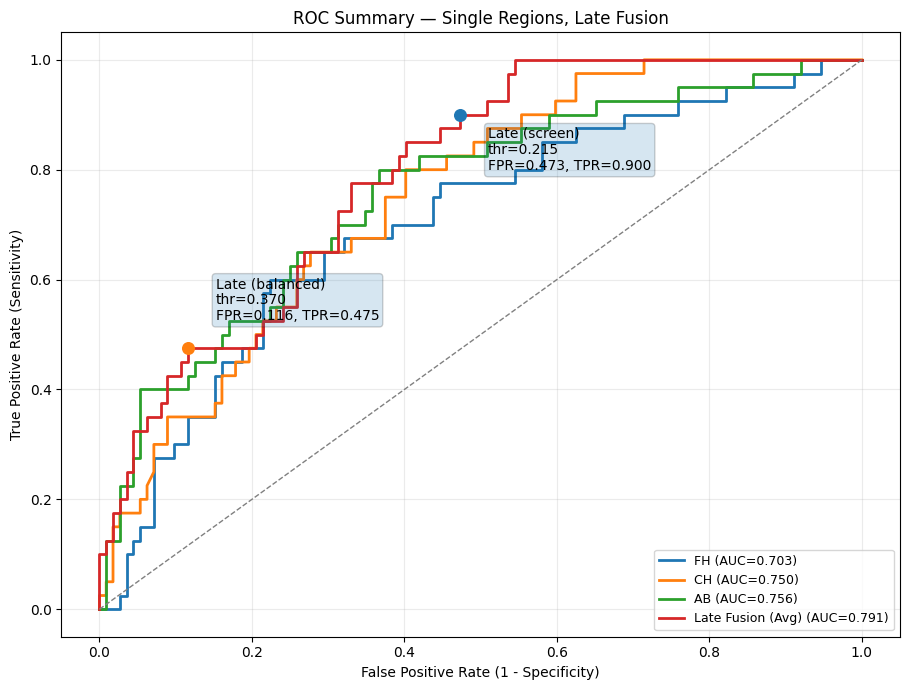

Saved: FINAL_ALLINONE_ROC.png


In [25]:
def point_on_roc_at_threshold(y_true, y_score, thr_value):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    idx = np.argmin(np.abs(thr - thr_value))
    return fpr[idx], tpr[idx], thr[idx]

LATE_SCREEN_THR = 0.210
LATE_BAL_THR = 0.357

curves = {
    "FH": prob_fh,
    "CH": prob_ch,
    "AB": prob_ab,
    "Late Fusion (Avg)": prob_avg
}

roc_data = {}
for name, score in curves.items():
    fpr_c, tpr_c, _ = roc_curve(y_test, score)
    roc_data[name] = (fpr_c, tpr_c, roc_auc_score(y_test, score))

ls_fpr, ls_tpr, ls_thr = point_on_roc_at_threshold(y_test, prob_avg, LATE_SCREEN_THR)
lb_fpr, lb_tpr, lb_thr = point_on_roc_at_threshold(y_test, prob_avg, LATE_BAL_THR)

plt.figure(figsize=(9.2, 7.0))

order = ["FH", "CH", "AB", "Late Fusion (Avg)"]
for name in order:
    fpr_c, tpr_c, a = roc_data[name]
    plt.plot(fpr_c, tpr_c, linewidth=2, label=f"{name} (AUC={a:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)

plt.scatter([ls_fpr], [ls_tpr], s=70, zorder=5)
plt.annotate(
    f"Late (screen)\nthr={ls_thr:.3f}\nFPR={ls_fpr:.3f}, TPR={ls_tpr:.3f}",
    (ls_fpr, ls_tpr),
    textcoords="offset points",
    xytext=(20, -40),
    ha="left",
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.18)
)

plt.scatter([lb_fpr], [lb_tpr], s=70, zorder=5)
plt.annotate(
    f"Late (balanced)\nthr={lb_thr:.3f}\nFPR={lb_fpr:.3f}, TPR={lb_tpr:.3f}",
    (lb_fpr, lb_tpr),
    textcoords="offset points",
    xytext=(20, 20),
    ha="left",
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.18)
)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Summary — Single Regions, Late Fusion")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("FINAL_ALLINONE_ROC.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: FINAL_ALLINONE_ROC.png")

Brier Score + Calibration Curve

Late Fusion Brier Score: 0.16276646841442335


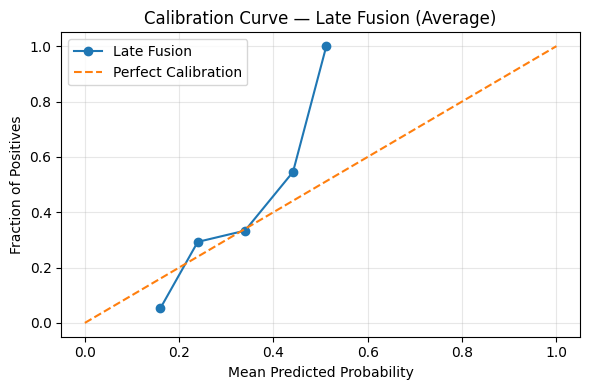

In [26]:
brier_late = brier_score_loss(y_test, prob_avg)
print("Late Fusion Brier Score:", brier_late)

frac_pos, mean_pred = calibration_curve(y_test, prob_avg, n_bins=10)

plt.figure(figsize=(6, 4))
plt.plot(mean_pred, frac_pos, "o-", label="Late Fusion")
plt.plot([0, 1], [0, 1], "--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Late Fusion (Average)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

95% CI for AUC

In [27]:
def auc_bootstrap_ci(y_true, y_prob, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true))
        y_b = y_true[idx]
        p_b = y_prob[idx]

        if len(np.unique(y_b)) < 2:
            continue

        aucs.append(roc_auc_score(y_b, p_b))

    return np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

auc_ci_low, auc_ci_high = auc_bootstrap_ci(y_test, prob_avg)
print(f"95% CI for AUC: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")

95% CI for AUC: [0.7167, 0.8594]


95% CI for Brier

In [28]:
boot_brier = []

for i in range(2000):
    y_res, p_res = resample(
        np.array(y_test),
        np.array(prob_avg),
        stratify=np.array(y_test),
        random_state=i
    )
    boot_brier.append(brier_score_loss(y_res, p_res))

brier_ci_low = np.percentile(boot_brier, 2.5)
brier_ci_high = np.percentile(boot_brier, 97.5)

print(f"95% CI for Brier Score: [{brier_ci_low:.4f}, {brier_ci_high:.4f}]")

95% CI for Brier Score: [0.1498, 0.1757]


Final Table 1 + Table 2 Values

In [29]:
late_auc = roc_auc_score(y_test, prob_avg)
late_brier = brier_score_loss(y_test, prob_avg)

fpr, tpr, thr = roc_curve(y_test, prob_avg)
j = tpr - fpr
best_idx = np.argmax(j)
best_thr = thr[best_idx]

y_pred = (prob_avg >= best_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
spec = tn / (tn + fp)
f1   = f1_score(y_test, y_pred, zero_division=0)
cm_final = [[int(tn), int(fp)], [int(fn), int(tp)]]

print("\nLate Fusion (avg) — Table 1")
print(f"Test AUC: {late_auc:.4f}")
print(f"95% CI (AUC): [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")
print(f"Brier score: {late_brier:.4f}")
print(f"95% CI (Brier): [{brier_ci_low:.4f}, {brier_ci_high:.4f}]")

print("\nLate Fusion (avg) — Table 2 (Youden J)")
print("Threshold rule: Youden J")
print(f"Threshold: {best_thr:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"Specificity: {spec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Confusion matrix: {cm_final}")


Late Fusion (avg) — Table 1
Test AUC: 0.7913
95% CI (AUC): [0.7167, 0.8594]
Brier score: 0.1628
95% CI (Brier): [0.1498, 0.1757]

Late Fusion (avg) — Table 2 (Youden J)
Threshold rule: Youden J
Threshold: 0.1958
Accuracy: 0.5987
Precision: 0.3960
Recall: 1.0000
Specificity: 0.4554
F1-score: 0.5674
Confusion matrix: [[51, 61], [0, 40]]


Optional CSV Save

In [ ]:
summary_table1 = pd.DataFrame([{
    "Approach": "Late Fusion (avg)",
    "Test AUC": round(late_auc, 4),
    "95% CI (AUC)": f"[{auc_ci_low:.4f}, {auc_ci_high:.4f}]",
    "Brier Score": round(late_brier, 4),
    "95% CI (Brier)": f"[{brier_ci_low:.4f}, {brier_ci_high:.4f}]"
}])

summary_table2 = pd.DataFrame([{
    "Approach": "Late Fusion (avg)",
    "Threshold rule": "Youden J",
    "Threshold": round(best_thr, 4),
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "Specificity": round(spec, 4),
    "F1-score": round(f1, 4),
    "Confusion matrix": str(cm_final)
}])

summary_table1.to_csv("late_fusion_table1.csv", index=False)
summary_table2.to_csv("late_fusion_table2.csv", index=False)

print("Saved: late_fusion_table1.csv")
print("Saved: late_fusion_table2.csv")
summary_table1, summary_table2

Optional Save Full Feature Table

In [ ]:
df_all.to_csv("late_fusion_combined_features.csv", index=False)
print("Saved: late_fusion_combined_features.csv")